Completed 25/500
Completed 50/500
Completed 75/500
Completed 100/500
Completed 125/500
Completed 150/500
Completed 175/500
Completed 200/500
Completed 225/500
Completed 250/500
Completed 275/500
Completed 300/500
Completed 325/500
Completed 350/500
Completed 375/500
Completed 400/500
Completed 425/500
Completed 450/500
Completed 475/500
Completed 500/500
MDE ≈ 3.183% (alpha=0.05, target power=80.0%)


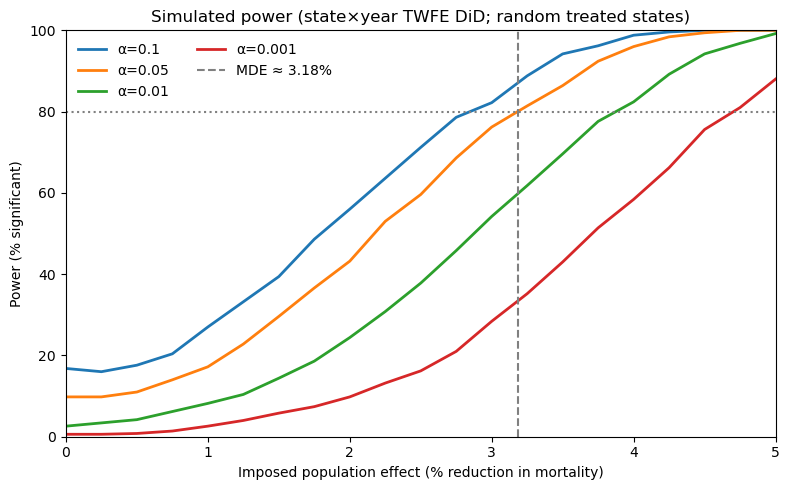

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t

# ----------------------------
# SETTINGS
# ----------------------------
DATA_PATH = "Multiple Cause of Death, 1999-2020.csv"
N_SIM = 500
N_TREATED = 23

FIRST_YEAR, LAST_YEAR = 2006, 2011          # pre: 2006-2010, post: 2011-2013
EFFECT_GRID = np.arange(0, 0.05001, 0.0025) # 0% to 5% by 0.25%
ALPHAS = [0.10, 0.05, 0.01, 0.001]
TARGET_POWER = 80.0
ALPHA_FOR_MDE = 0.05

rng = np.random.default_rng(1234)

# ----------------------------
# LOAD + CLEAN
# ----------------------------
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df = df[df["year"].notna()].copy()
df["year"] = df["year"].astype(int)

df["deaths"] = pd.to_numeric(df["deaths"], errors="coerce")
df["population"] = pd.to_numeric(df["population"], errors="coerce")
df = df.dropna(subset=["deaths", "population"])

df = df[(df["year"] >= FIRST_YEAR) & (df["year"] < 2014)].copy()
df["state_id"] = pd.to_numeric(df["state_code"], errors="coerce").astype(int)

# indices for fast group ops
state_codes = np.sort(df["state_id"].unique())
year_vals = np.sort(df["year"].unique())
state_to_idx = {s:i for i,s in enumerate(state_codes)}
year_to_idx  = {y:i for i,y in enumerate(year_vals)}

s = df["state_id"].map(state_to_idx).to_numpy()
tt = df["year"].map(year_to_idx).to_numpy()
S, T = len(state_codes), len(year_vals)

deaths0 = df["deaths"].to_numpy().astype(int)
pop = df["population"].to_numpy().astype(float)
w = pop
post = (df["year"].to_numpy() >= LAST_YEAR).astype(int)

# ----------------------------
# TWFE (1 regressor) with cluster-by-state variance
# ----------------------------
def twoway_demean(x):
    x_bar = (w * x).sum() / w.sum()
    xs = np.bincount(s, weights=w * x, minlength=S) / np.bincount(s, weights=w, minlength=S)
    xt = np.bincount(tt, weights=w * x, minlength=T) / np.bincount(tt, weights=w, minlength=T)
    return x - xs[s] - xt[tt] + x_bar

def twfe_beta_se(y, d):
    yt = twoway_demean(y)
    dt = twoway_demean(d)

    bread = np.sum(w * dt * dt)
    beta = np.sum(w * dt * yt) / bread

    u = yt - beta * dt
    score_g = np.bincount(s, weights=(w * dt * u), minlength=S)
    var_beta = np.sum(score_g**2) / (bread**2)

    return beta, np.sqrt(var_beta), (S - 1)

# ----------------------------
# SIMULATE p-values for each effect size
# ----------------------------
J = len(EFFECT_GRID)
pvals = np.empty((N_SIM, J))

state_idx = np.arange(S)

Bhat = np.empty((N_SIM, J))   # store b_pct
SEhat = np.empty((N_SIM, J))  # store se_pct

for k in range(N_SIM):
    treated_states = rng.choice(state_idx, size=N_TREATED, replace=False)
    treated = np.isin(s, treated_states).astype(int)
    d = treated * post  # TreatPost regressor

    for j, eff in enumerate(EFFECT_GRID):
        removed = rng.binomial(n=deaths0, p=eff) * d
        deaths_eff = deaths0 - removed
        y = np.log((deaths_eff / pop) * 100000.0 + 1.0)

        beta, se_beta, df_t = twfe_beta_se(y, d)

        # Stata uses nlcom 100*(exp(beta)-1)
        b_pct = 100.0 * (np.exp(beta) - 1.0)
        se_pct = 100.0 * np.exp(beta) * se_beta
        tstat = b_pct / se_pct
        pvals[k, j] = 2 * t.sf(np.abs(tstat), df=df_t)
        
        Bhat[k, j] = b_pct
        SEhat[k, j] = se_pct
        
    if (k + 1) % 25 == 0:
        print(f"Completed {k+1}/{N_SIM}")

# ----------------------------
# POWER TABLE
# ----------------------------
out = pd.DataFrame({"effect_size_pct": EFFECT_GRID * 100})

for a in ALPHAS:
    out[f"power_{a:.3f}"] = (pvals <= a).mean(axis=0) * 100

# ----------------------------
# MDE (linear interpolation around 80% power at alpha=0.05)
# ----------------------------
powcol = f"power_{ALPHA_FOR_MDE:.3f}"
gap = np.abs(out[powcol] - TARGET_POWER)
i1, i2 = np.argsort(gap.values)[:2]
x1, x2 = out.loc[[i1, i2], "effect_size_pct"].values
y1, y2 = out.loc[[i1, i2], powcol].values

m = (y2 - y1) / (x2 - x1)
c = y1 - m * x1
mde = (TARGET_POWER - c) / m

print(f"MDE ≈ {mde:.3f}% (alpha={ALPHA_FOR_MDE}, target power={TARGET_POWER}%)")

# ----------------------------
# PLOT
# ----------------------------
plt.figure(figsize=(8, 5))
for a in ALPHAS:
    plt.plot(out["effect_size_pct"], out[f"power_{a:.3f}"], lw=2, label=f"α={a:g}")

plt.axvline(mde, color="gray", ls="--", lw=1.5, label=f"MDE ≈ {mde:.2f}%")
plt.axhline(TARGET_POWER, color="gray", ls=":", lw=1.5)

plt.ylim(0, 100)
plt.xlim(0, out["effect_size_pct"].max())
plt.xlabel("Imposed population effect (% reduction in mortality)")
plt.ylabel("Power (% significant)")
plt.title("Simulated power (state×year TWFE DiD; random treated states)")
plt.legend(frameon=False, ncols=2)
plt.tight_layout()
plt.show()


In [2]:
def summarize_at_effect(effect_pct):
    j = np.where(np.isclose(out["effect_size_pct"].values, effect_pct))[0][0]
    print(f"\n=== Effect={effect_pct:.2f}% imposed ===")
    print("Mean b_hat (%):", np.mean(Bhat[:, j]))
    print("SD   b_hat (%):", np.std(Bhat[:, j]))
    print("Mean se_hat (%):", np.mean(SEhat[:, j]))
    for a in ALPHAS:
        rej = np.mean(pvals[:, j] <= a)
        print(f"Reject rate at alpha={a:g}: {100*rej:.1f}%")

summarize_at_effect(0.00)
summarize_at_effect(2.50)
summarize_at_effect(5.00)


=== Effect=0.00% imposed ===
Mean b_hat (%): 0.0155891678757583
SD   b_hat (%): 1.1948123972021705
Mean se_hat (%): 1.0702826944034123
Reject rate at alpha=0.1: 16.8%
Reject rate at alpha=0.05: 9.8%
Reject rate at alpha=0.01: 2.6%
Reject rate at alpha=0.001: 0.6%

=== Effect=2.50% imposed ===
Mean b_hat (%): -2.4738896068005394
SD   b_hat (%): 1.1641753340298244
Mean se_hat (%): 1.0432428289166984
Reject rate at alpha=0.1: 71.2%
Reject rate at alpha=0.05: 59.6%
Reject rate at alpha=0.01: 37.8%
Reject rate at alpha=0.001: 16.2%

=== Effect=5.00% imposed ===
Mean b_hat (%): -4.964050088808952
SD   b_hat (%): 1.135025003327136
Mean se_hat (%): 1.0167711732520623
Reject rate at alpha=0.1: 100.0%
Reject rate at alpha=0.05: 100.0%
Reject rate at alpha=0.01: 99.2%
Reject rate at alpha=0.001: 88.0%


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def interp1(x, y, x0):
    """Simple linear interpolation; assumes x sorted ascending."""
    return np.interp(x0, x, y, left=np.nan, right=np.nan)

def mde_from_power_curve(out, alpha, target_power=80.0):
    """
    Invert the simulated power curve to get MDE at given alpha and target_power.
    Uses local linear interpolation around the two closest points to target_power.
    Returns MDE in percent units (same units as effect_size_pct).
    """
    col = f"power_{alpha:.3f}"
    if col not in out.columns:
        raise KeyError(f"Missing column {col}. Have: {out.columns.tolist()}")

    gap = np.abs(out[col] - target_power)
    i1, i2 = np.argsort(gap.values)[:2]
    x1, x2 = out.loc[[i1, i2], "effect_size_pct"].values
    y1, y2 = out.loc[[i1, i2], col].values

    m = (y2 - y1) / (x2 - x1)
    b = y1 - m * x1
    return float((target_power - b) / m)

def power_at_effect(out, alpha, effect_pct):
    """Interpolate simulated power at an arbitrary effect size (in percent)."""
    col = f"power_{alpha:.3f}"
    return float(interp1(out["effect_size_pct"].values, out[col].values, effect_pct))

def effect_from_budget(budget, N_pop, kappa, c):
    """
    budget: dollars
    N_pop: persons
    kappa = r*tau (unitless, e.g. 0.10)
    c: dollars per enrollee-year
    Returns implied beta_pop in percent units.
    """
    dN = budget / c
    f = dN / N_pop
    beta = f * kappa                # in share units
    return 100.0 * beta             # convert to percent

def power_at_budget(out, alpha, budget, N_pop, kappa, c):
    eff_pct = effect_from_budget(budget, N_pop, kappa, c)
    return power_at_effect(out, alpha, eff_pct)

def power_at_dN(out, alpha, dN, N_pop, kappa):
    eff_pct = 100.0 * (dN / N_pop) * kappa
    return power_at_effect(out, alpha, eff_pct)

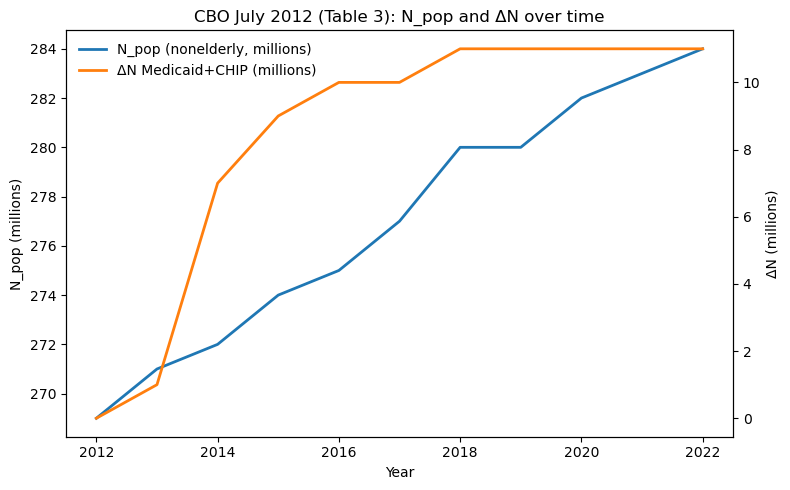

    year  N_pop_millions  dN_medicaid_millions         f
0   2012           269.0                   0.0  0.000000
1   2013           271.0                   1.0  0.003690
2   2014           272.0                   7.0  0.025735
3   2015           274.0                   9.0  0.032847
4   2016           275.0                  10.0  0.036364
5   2017           277.0                  10.0  0.036101
6   2018           280.0                  11.0  0.039286
7   2019           280.0                  11.0  0.039286
8   2020           282.0                  11.0  0.039007
9   2021           283.0                  11.0  0.038869
10  2022           284.0                  11.0  0.038732


In [4]:
years = np.arange(2012, 2023)

# July 2012 Table 3: TOTAL nonelderly population (millions)
N_pop_m = np.array([269, 271, 272, 274, 275, 277, 280, 280, 282, 283, 284], dtype=float)

# July 2012 Table 3: Change in coverage Medicaid and CHIP under ACA (millions)
# 2012 is "*", treat as 0 for plotting; feel free to set NaN instead.
dN_m = np.array([0, 1, 7, 9, 10, 10, 11, 11, 11, 11, 11], dtype=float)

panel = pd.DataFrame({
    "year": years,
    "N_pop_millions": N_pop_m,
    "dN_medicaid_millions": dN_m,
})
panel["f"] = panel["dN_medicaid_millions"] / panel["N_pop_millions"]

fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(panel["year"], panel["N_pop_millions"], lw=2, label="N_pop (nonelderly, millions)")
ax1.set_ylabel("N_pop (millions)")
ax1.set_xlabel("Year")

ax2 = ax1.twinx()
ax2.plot(panel["year"], panel["dN_medicaid_millions"], lw=2, color="C1", label="ΔN Medicaid+CHIP (millions)")
ax2.set_ylabel("ΔN (millions)")

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines+lines2, labels+labels2, frameon=False, loc="upper left")

plt.title("CBO July 2012 (Table 3): N_pop and ΔN over time")
plt.tight_layout()
plt.show()

print(panel)

In [5]:
ALPHAS = [0.10, 0.05, 0.01, 0.001]
TARGET_POWERS = [50.0, 80.0, 90.0]

# CBO July 2012 Table 3 TOTAL nonelderly in 2022:
N_pop_2022 = 284_000_000

# choose kappa values
kappa_grid = [0.05, 0.10, 0.20]

# choose cost per enrollee-year (fixed for the “alpha->budget” normativity mapping)
c_fixed = 6000.0

rows = []
for tp in TARGET_POWERS:
    for a in ALPHAS:
        mde_pct = mde_from_power_curve(out, a, target_power=tp)
        mde = mde_pct / 100.0
        for kappa in kappa_grid:
            f_min = mde / kappa
            dN_min = f_min * N_pop_2022
            B_min  = c_fixed * dN_min
            rows.append({
                "alpha": a,
                "target_power": tp,
                "mde_pct": mde_pct,
                "kappa": kappa,
                "f_min": f_min,
                "N_pop": N_pop_2022,
                "dN_min": dN_min,
                "c": c_fixed,
                "budget_min": B_min
            })

alpha_budget_tp = pd.DataFrame(rows)
alpha_budget_tp.to_csv("alpha_budget_multi_targetpower.csv", index=False)
alpha_budget_tp.head()

,alpha,target_power,mde_pct,kappa,f_min,N_pop,dN_min,c,budget_min
0,0.10,50.0,1.797297,0.05,0.359459,284000000,1.020865e+08,6000.0,6.125189e+11
1,0.10,50.0,1.797297,0.10,0.179730,284000000,5.104324e+07,6000.0,3.062595e+11
2,0.10,50.0,1.797297,0.20,0.089865,284000000,2.552162e+07,6000.0,1.531297e+11
3,0.05,50.0,2.173469,0.05,0.434694,284000000,1.234531e+08,6000.0,7.407184e+11
4,0.05,50.0,2.173469,0.10,0.217347,284000000,6.172653e+07,6000.0,3.703592e+11


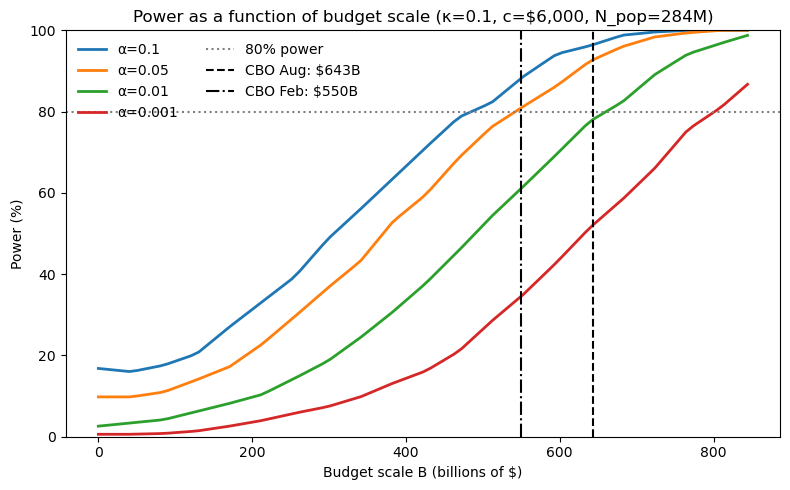

In [6]:
# --- settings for this figure ---
kappa_fix = 0.10
c_fix = 6000.0
N_pop = N_pop_2022

# CBO Aug vs Feb (Table A-2, 10-year Medicaid+CHIP outlays)
B_aug = 643e9
B_feb = 550e9

budget_grid = np.linspace(0, 2.0e12, 200)  # $0 to $2T

plt.figure(figsize=(8,5))
for a in ALPHAS:
    pw = [power_at_budget(out, a, B, N_pop=N_pop, kappa=kappa_fix, c=c_fix) for B in budget_grid]
    plt.plot(budget_grid/1e9, pw, lw=2, label=f"α={a:g}")

plt.axhline(80, color="gray", ls=":", lw=1.5, label="80% power")
plt.axvline(B_aug/1e9, color="black", ls="--", lw=1.5, label="CBO Aug: $643B")
plt.axvline(B_feb/1e9, color="black", ls="-.", lw=1.5, label="CBO Feb: $550B")

plt.ylim(0,100)
plt.xlabel("Budget scale B (billions of $)")
plt.ylabel("Power (%)")
plt.title(f"Power as a function of budget scale (κ={kappa_fix}, c=${c_fix:,.0f}, N_pop=284M)")
plt.legend(frameon=False, ncols=2)
plt.tight_layout()
plt.show()

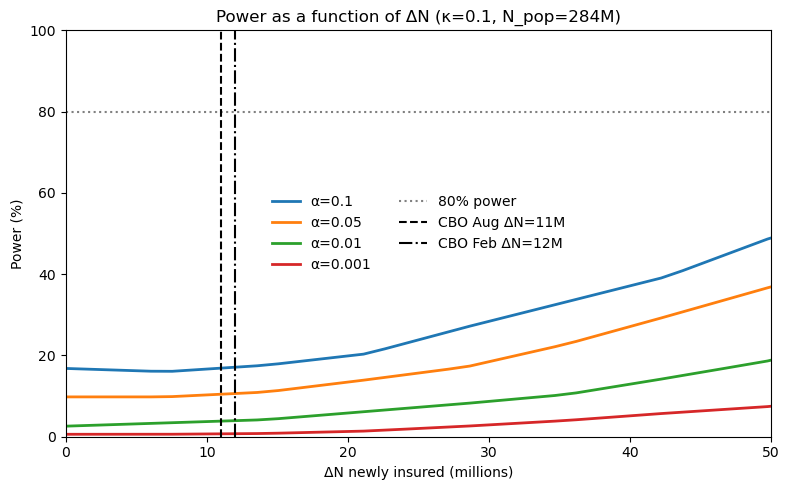

In [7]:
dN_grid = np.linspace(0, 300e6, 200)  # 0 to 300M newly insured (very wide; adjust)

plt.figure(figsize=(8,5))
for a in ALPHAS:
    pw = [power_at_dN(out, a, dN, N_pop=N_pop, kappa=kappa_fix) for dN in dN_grid]
    plt.plot(dN_grid/1e6, pw, lw=2, label=f"α={a:g}")

plt.axhline(80, color="gray", ls=":", lw=1.5, label="80% power")

# CBO Aug vs Feb ΔN in 2022 from Table A-2: 11M vs 12M
plt.axvline(11, color="black", ls="--", lw=1.5, label="CBO Aug ΔN=11M")
plt.axvline(12, color="black", ls="-.", lw=1.5, label="CBO Feb ΔN=12M")

plt.ylim(0,100)
plt.xlim(0, 50)  # zoom; the action is near 0-30 usually
plt.xlabel("ΔN newly insured (millions)")
plt.ylabel("Power (%)")
plt.title(f"Power as a function of ΔN (κ={kappa_fix}, N_pop=284M)")
plt.legend(frameon=False, ncols=2)
plt.tight_layout()
plt.show()

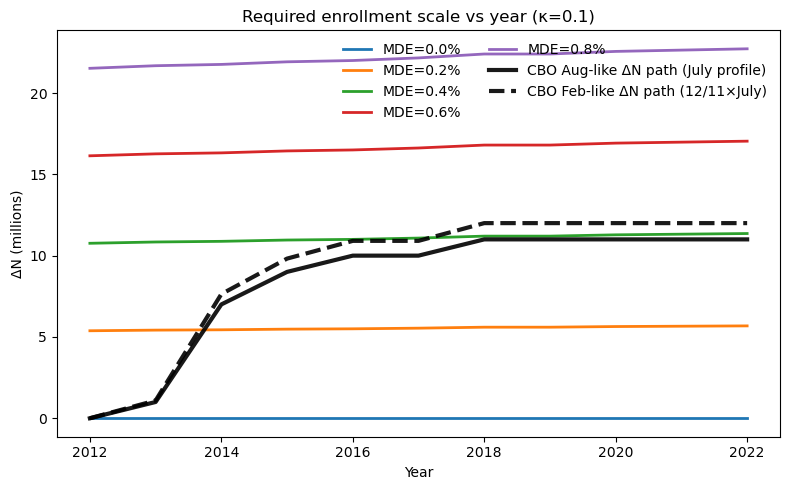

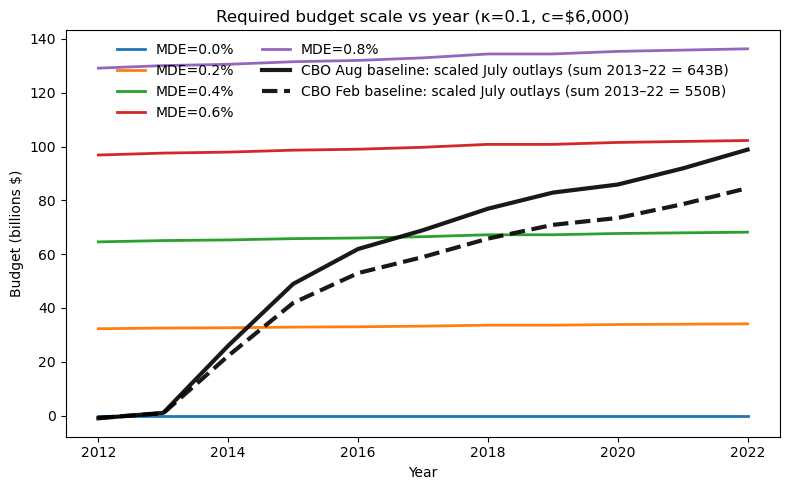

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# CBO July 2012 table inputs (hard-coded)
# ----------------------------
years = np.arange(2012, 2023)

# Table 3: TOTAL nonelderly pop (millions) and Medicaid+CHIP change under ACA (millions)
N_pop_m = np.array([269,271,272,274,275,277,280,280,282,283,284], dtype=float)
dN_m    = np.array([0,  1,  7,  9, 10, 10, 11, 11, 11, 11, 11], dtype=float)

# Table 4: Medicaid+CHIP outlays attributable to coverage provisions (billions, fiscal yrs)
B_cbo_B = np.array([-1, 1, 26, 49, 62, 69, 77, 83, 86, 92, 99], dtype=float) * 1e9

cbo = pd.DataFrame({
    "year": years,
    "N_pop": N_pop_m * 1e6,      # persons
    "dN": dN_m * 1e6,            # persons
    "B_cbo": B_cbo_B             # dollars
})
cbo["f"] = cbo["dN"] / cbo["N_pop"]

# ----------------------------
# Assumptions for detectability mapping
# ----------------------------
kappa_fix = 0.10         # κ = r*tau
c_fix = 6000.0           # $ per enrollee-year (stylized)

# ----------------------------
# ORIGINAL vs REVISED SCALING (MINIMAL ASSUMPTION)
# ----------------------------
# Feb 2013 Table A-2 (10y totals, 2013-2022): Medicaid+CHIP outlays 643B (Aug 2012) vs 550B (Feb 2013).
# Also Table A-2 (2022 coverage): Medicaid+CHIP change under ACA is 11M (Aug 2012) vs 12M (Feb 2013).
#
# We DO NOT observe revised annual paths in Table A-2, so we impose:
#   (i) revised annual outlay path = (constant)×(July 2012 annual profile) so that 2013-2022 sum matches Table A-2 total
#   (ii) revised annual enrollment path = (12/11)×(July 2012 enrollment profile), so 2022 matches Table A-2

B10_aug = 643e9
B10_feb = 550e9
scale_B_aug = B10_aug / cbo.loc[(cbo["year"]>=2013) & (cbo["year"]<=2022), "B_cbo"].sum()
scale_B_feb = B10_feb / cbo.loc[(cbo["year"]>=2013) & (cbo["year"]<=2022), "B_cbo"].sum()

scale_dN_feb = 12/11  # 2022 Medicaid+CHIP change: 12M vs 11M

# Construct the two black lines
cbo["dN_aug"] = cbo["dN"]                  # treat July profile as "Aug-like" enrollment path
cbo["dN_feb"] = scale_dN_feb * cbo["dN"]   # scaled enrollment path

cbo["B_aug"]  = scale_B_aug * cbo["B_cbo"] # scaled to 643B over 2013-2022
cbo["B_feb"]  = scale_B_feb * cbo["B_cbo"] # scaled to 550B over 2013-2022

# MDE grid in PERCENT
mde_grid_pct = np.arange(0.25, 5.01, 0.25)

# ----------------------------
# Plot 1: Required ΔN_min,t vs year
# ----------------------------
plt.figure(figsize=(8,5))

mde_show = np.arange(0, .81, 0.2)  # (you can change this)

for mde_pct in mde_show:
    mde = mde_pct / 100.0
    dN_min = cbo["N_pop"] * (mde / kappa_fix)
    plt.plot(cbo["year"], dN_min/1e6, lw=2, label=f"MDE={mde_pct:.1f}%")

# two black lines (original vs revised enrollment paths)
plt.plot(cbo["year"], cbo["dN_aug"]/1e6, color="black", lw=3, alpha=0.9, label="CBO Aug-like ΔN path (July profile)")
plt.plot(cbo["year"], cbo["dN_feb"]/1e6, color="black", lw=3, ls="--", alpha=0.9, label="CBO Feb-like ΔN path (12/11×July)")

plt.xlabel("Year")
plt.ylabel("ΔN (millions)")
plt.title(f"Required enrollment scale vs year (κ={kappa_fix:g})")
plt.legend(frameon=False, ncols=2)
plt.tight_layout()
plt.show()

# ----------------------------
# Plot 2: Required B_min,t vs year
# ----------------------------
plt.figure(figsize=(8,5))

for mde_pct in mde_show:
    mde = mde_pct / 100.0
    B_min = c_fix * cbo["N_pop"] * (mde / kappa_fix)
    plt.plot(cbo["year"], B_min/1e9, lw=2, label=f"MDE={mde_pct:.1f}%")

# two black lines (original vs revised outlay paths)
plt.plot(cbo["year"], cbo["B_aug"]/1e9, color="black", lw=3, alpha=0.9,
         label="CBO Aug baseline: scaled July outlays (sum 2013–22 = 643B)")
plt.plot(cbo["year"], cbo["B_feb"]/1e9, color="black", lw=3, ls="--", alpha=0.9,
         label="CBO Feb baseline: scaled July outlays (sum 2013–22 = 550B)")

plt.xlabel("Year")
plt.ylabel("Budget (billions $)")
plt.title(f"Required budget scale vs year (κ={kappa_fix:g}, c=${c_fix:,.0f})")
plt.legend(frameon=False, ncols=2)
plt.tight_layout()
plt.show()